# Домашнее задание 6.1: Линейные модели и методы оптимизации

**Школа глубокого обучения ФПМИ МФТИ**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

%matplotlib inline

In [2]:
np.random.seed(42)

# Градиентный спуск: повторение

Рассмотрим функцию $f(x, y) = \sin^2(x) + \sin^2(y)$

In [3]:
def f(r):
    """
    :param r: np.array(np.float) вектор длины 2
    :return: np.float

    На вход функции мы подаем двумерный массив: r = [x,y]
    """
    return np.sum(np.sin(r)**2)

## Задание 1

Реализуйте функцию `grad_f`, вычисляющую градиент функции $f$ аналитически.

$$\frac{\partial f}{\partial x} = 2 \sin(x) \cos(x) = \sin(2x)$$
$$\frac{\partial f}{\partial y} = 2 \sin(y) \cos(y) = \sin(2y)$$

In [4]:
# Функция, вычисляющая градиент

def grad_f(r):
    """
    Градиент функции f, определённой выше.
    :param r: np.array[2]: float вектор длины 2
    :return: np.array[2]: float вектор длины 2
    """
    return np.array([np.sin(2 * r[0]), np.sin(2 * r[1])])

In [5]:
# Проверим, что градиент принимает вектор из двух чисел и выдает на этой точке верное значение
assert np.allclose(grad_f(np.array([1, 2])),
                   np.array([0.90929743, -0.7568025])), "Что-то не так!"
print("Задание 1 пройдено!")

Задание 1 пройдено!


## Задание 2

Реализуйте градиентный спуск для функции от двух переменных.

In [6]:
def grad_descent_2d(f, grad_f, lr, num_iter=100, r0=None):
    """
    Функция, реализующая градиентный спуск для функции f от двух переменных.
        :param f: скалярная функция двух переменных
        :param grad_f: функция, возвращающая градиент функции f
        :param lr: learning rate алгоритма
        :param num_iter: количество итераций градиентного спуска
        :param r0: начальное значение аргумента f(r)
        :return: np.array[num_iter, 3] — тройки (x, y, f(x,y))
    """
    if r0 is None:
        r0 = np.random.random(2)

    history = []
    curr_r = r0.copy()

    for iter_num in range(num_iter):
        entry = np.hstack((curr_r, f(curr_r)))
        history.append(entry)
        curr_r -= lr * grad_f(curr_r)

    return np.vstack(history)

### Тестируем написанную функцию

In [7]:
steps = grad_descent_2d(f, grad_f, lr=0.1, num_iter=20)

In [8]:
# Посмотрим, что из себя представляет вывод функции:
pd.DataFrame(data=steps, columns=['x', 'y', 'f([x,y])'])

,x,y,"f([x,y])"
0,0.374540,0.950714,0.796163
1,0.306444,0.856131,0.661501
2,0.248920,0.757130,0.532439
3,0.201167,0.657289,0.413214
4,0.162011,0.560554,0.308676
5,0.130173,0.470496,0.222356
6,0.104431,0.389681,0.155185
7,0.083696,0.319399,0.105582
8,0.067035,0.259776,0.070466
9,0.053668,0.210127,0.046385


### Визуализация: 3D график с точками градиентного спуска

In [9]:
import plotly.graph_objects as go

# Создание сетки
border = 1.5
X_grid, Y_grid = np.meshgrid(np.linspace(-border, border, 100), np.linspace(-border, border, 100))
Z_grid = np.array([f(np.array([x, y])) for x, y in zip(np.ravel(X_grid), np.ravel(Y_grid))]).reshape(X_grid.shape)

# Создание 3D-графика
fig = go.Figure(data=[
    go.Surface(z=Z_grid, x=X_grid, y=Y_grid, colorscale='Viridis')
])

# Добавление линии и маркеров
fig.add_trace(go.Scatter3d(
    x=steps[:, 0],
    y=steps[:, 1],
    z=steps[:, 2],
    mode='lines+markers',
    marker=dict(size=8, color='red', symbol='cross'),
    line=dict(color='black', width=5)
))

fig.update_layout(
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        zaxis=dict(range=[-1, 5]),
        aspectratio=dict(x=1, y=1, z=0.7)
    ),
    margin=dict(l=0, r=0, b=0, t=0)
)

fig.show()

### График значений функции от шага

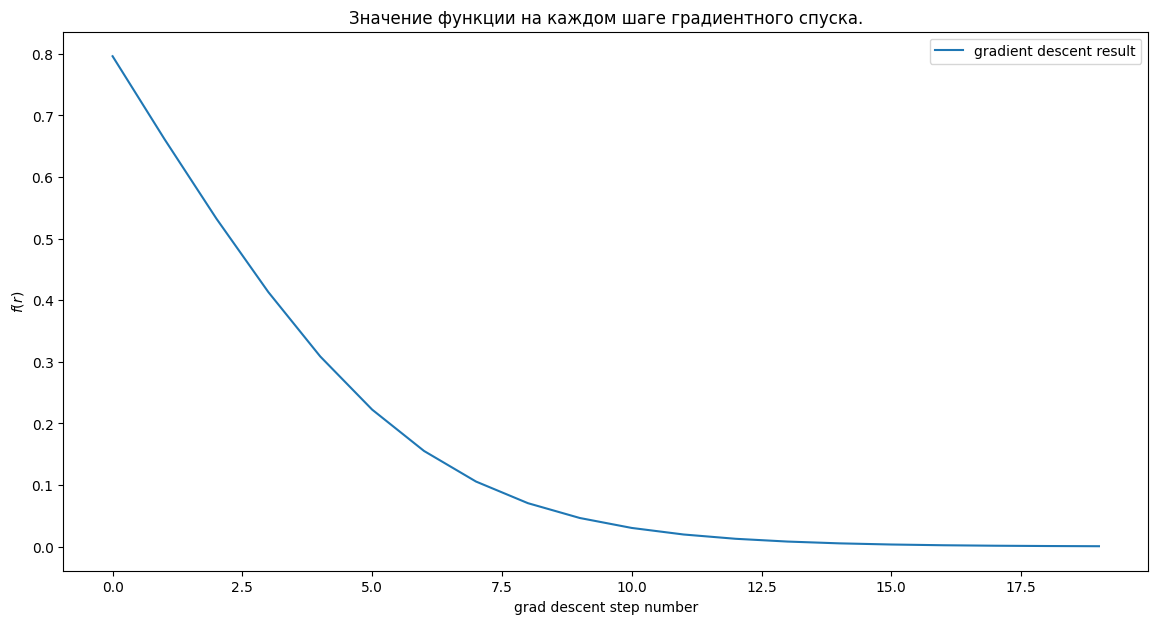

In [10]:
plt.figure(figsize=(14, 7))
plt.xlabel('grad descent step number')
plt.ylabel('$f(r)$')
plt.title('Значение функции на каждом шаге градиентного спуска.')

f_values = list(map(lambda x: x[2], steps))
plt.plot(f_values, label='gradient descent result')
plt.legend()
plt.show()

# Генератор батчей

## Задание 3

Реализуйте генератор батчей. Последний неполный батч не возвращаем.

In [11]:
def generate_batches(X, y, batch_size):
    """
    param X: np.array[n_objects, n_features] --- матрица объекты-признаки
    param y: np.array[n_objects] --- вектор целевых переменных
    """
    assert len(X) == len(y)
    np.random.seed(42)
    X = np.array(X)
    y = np.array(y)
    perm = np.random.permutation(len(X))

    for batch_start in range(0, len(X) - batch_size + 1, batch_size):
        batch_indices = perm[batch_start:batch_start + batch_size]
        yield X[batch_indices], y[batch_indices]

### Тестируем написанную функцию

In [12]:
# Тест 1: batch_size делит размер датасета нацело
X_fake = np.arange(100)[:, np.newaxis]
y_fake = np.arange(100) + 1000

X_reconstructed, y_reconstructed = [], []
for X_batch, y_batch in generate_batches(X_fake, y_fake, 10):
    X_reconstructed.append(X_batch)
    y_reconstructed.append(y_batch)

X_reconstructed = np.concatenate(X_reconstructed)
y_reconstructed = np.concatenate(y_reconstructed)

assert (X_fake != X_reconstructed).all(), "Что-то не так!"
assert (y_fake != y_reconstructed).all(), "Что-то не так!"

assert (np.sort(X_reconstructed, axis=0) == X_fake).all(), "Что-то не так!"
print("Тест 1 (batch_size=10) пройден!")

Тест 1 (batch_size=10) пройден!


In [13]:
# Тест 2: batch_size НЕ делит размер датасета нацело — последний неполный батч отбрасывается
X_fake = np.arange(100)[:, np.newaxis]
y_fake = np.arange(100) + 1000

num_batches = 0
for X_batch, y_batch in generate_batches(X_fake, y_fake, 7):
    num_batches += 1

assert num_batches == len(X_fake) // 7, "Что-то не так!"
print(f"Тест 2 (batch_size=7) пройден! Количество батчей: {num_batches}")

Тест 2 (batch_size=7) пройден! Количество батчей: 14


# Обычная логистическая регрессия

## Задание 4

Реализуйте методы `fit` и `get_grad` класса `MyLogisticRegression`.

In [14]:
def logit(x, w):
    return np.dot(x, w)

def sigmoid(h):
    return 1. / (1 + np.exp(-h))

In [15]:
from sklearn.base import BaseEstimator, ClassifierMixin


class MyLogisticRegression(BaseEstimator, ClassifierMixin):
    def __init__(self):
        self.w = None

    def fit(self, X, y, epochs=10, lr=0.1, batch_size=100):
        l, n = X.shape
        if self.w is None:
            np.random.seed(42)
            self.w = np.random.randn(n + 1)

        X_train = np.concatenate((np.ones((l, 1)), X), axis=1)

        losses = []

        for i in range(epochs):
            for X_batch, y_batch in generate_batches(X_train, y, batch_size):
                predictions = sigmoid(logit(X_batch, self.w))
                loss = self.__loss(y_batch, predictions)

                assert (np.array(loss).shape == tuple()), "Лосс должен быть скаляром!"

                losses.append(loss)
                self.w -= lr * self.get_grad(X_batch, y_batch, predictions)

        self.losses_ = losses
        self.is_fitted_ = True
        return losses

    def get_grad(self, X_batch, y_batch, predictions):
        """
        Градиент функции потерь логистической регрессии.
        Сумма, не среднее!
        """
        grad_basic = X_batch.T @ (predictions - y_batch)

        assert grad_basic.shape == (X_batch.shape[1],), \
            "Градиенты должны быть столбцом из k_features + 1 элементов"

        return grad_basic

    def predict_proba(self, X):
        l, n = X.shape
        X_ = np.concatenate((np.ones((l, 1)), X), axis=1)
        return sigmoid(logit(X_, self.w))

    def _predict_proba_internal(self, X):
        return sigmoid(logit(X, self.w))

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def get_weights(self):
        return self.w.copy()

    def __loss(self, y, p):
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

### Тестируем get_grad

In [16]:
# Тест 1: X с добавленной колонкой единиц
m = MyLogisticRegression()
X = np.array([[1, 3, 4], [1, -5, 6], [-3, 5, 3]])
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.array([1, 0, 1])
preds = np.array([.55, .22, .85])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([-0.38,  0.22, -3.2 , -0.93])), "Что-то не так!"
print(f"Тест 1 пройден! grads = {grads}")

Тест 1 пройден! grads = [-0.38  0.22 -3.2  -0.93]


In [17]:
# Тест 2: X без колонки единиц
np.random.seed(42)
m = MyLogisticRegression()
X = np.random.rand(100,3)
y = np.random.randint(0, 1, size=(100,))
preds = np.random.rand(100)
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([23.8698149, 25.27049356, 24.4139452])), "Что-то не так!"
print(f"Тест 2 пройден! grads = {grads}")

Тест 2 пройден! grads = [23.8698149  25.27049356 24.4139452 ]


# Логистическая регрессия с $l_1$ и $l_2$ регуляризацией (elastic net)

## Задание 5

Реализуйте `get_grad` и `__loss` для `MyElasticLogisticRegression`.

- Bias (w₀) **не входит** в регуляризационные слагаемые.
- Градиент — **сумма**, не среднее.

In [18]:
class MyElasticLogisticRegression(MyLogisticRegression):
    def __init__(self, l1_coef=0.01, l2_coef=0.01):
        self.l1_coef = l1_coef
        self.l2_coef = l2_coef
        self.w = None

    def _MyLogisticRegression__loss(self, y, p):
        """Переопределяем приватный __loss родителя (name mangling)."""
        p = np.clip(p, 1e-10, 1 - 1e-10)
        return (-np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
                + self.l1_coef * np.sum(np.abs(self.w[1:]))
                + self.l2_coef * np.sum(self.w[1:] ** 2))

    def get_grad(self, X_batch, y_batch, predictions):
        """
        Градиент функции потерь с L1 и L2 регуляризацией.
        Bias (w₀) не входит в регуляризационные слагаемые.
        """
        # Базовый градиент логрегрессии (bias-компоненту НЕ обнуляем)
        grad_basic = X_batch.T @ (predictions - y_batch)

        # L1-регуляризация: grad = l1_coef * sign(w), с обнулённым bias
        grad_l1 = self.l1_coef * np.sign(self.w)
        grad_l1[0] = 0

        # L2-регуляризация: grad = 2 * l2_coef * w, с обнулённым bias
        grad_l2 = 2 * self.l2_coef * self.w
        grad_l2[0] = 0

        assert grad_l1[0] == grad_l2[0] == 0, "Bias в регуляризационные слагаемые не входит!"
        assert grad_basic.shape == grad_l1.shape == grad_l2.shape == (X_batch.shape[1],), \
            "Градиенты должны быть столбцом из k_features + 1 элементов"

        return grad_basic + grad_l1 + grad_l2

### Тестирование

In [19]:
# Тест 1
m = MyElasticLogisticRegression(.2, .2)
X = np.array([[1, 3, 4], [1, -5, 6], [-3, 5, 3]])
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.array([1, 0, 1])
preds = np.array([.55, .22, .85])
m.w = np.array([1, 1, 1, 1])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([-0.38,  0.82, -2.6 , -0.33])), "Что-то не так!"
print(f"Тест 1 пройден! grads = {grads}")

Тест 1 пройден! grads = [-0.38  0.82 -2.6  -0.33]


In [20]:
# Тест 2
np.random.seed(42)
m = MyElasticLogisticRegression(.2, .2)
X = np.random.rand(100, 3)
X = np.concatenate((np.ones((X.shape[0], 1)), X), axis=1)
y = np.random.randint(0, 1, size=(100,))
preds = np.random.rand(100)
m.w = np.array([1, 1, 1, 1])
grads = m.get_grad(X, y, preds)
assert np.allclose(grads, np.array([49.11489408, 24.4698149, 25.87049356, 25.0139452])), "Что-то не так!"
print(f"Тест 2 пройден! grads = {grads}")

Тест 2 пройден! grads = [49.11489408 24.4698149  25.87049356 25.0139452 ]


## Смотрим, как работает наша модель

Протестируем на искусственных данных:

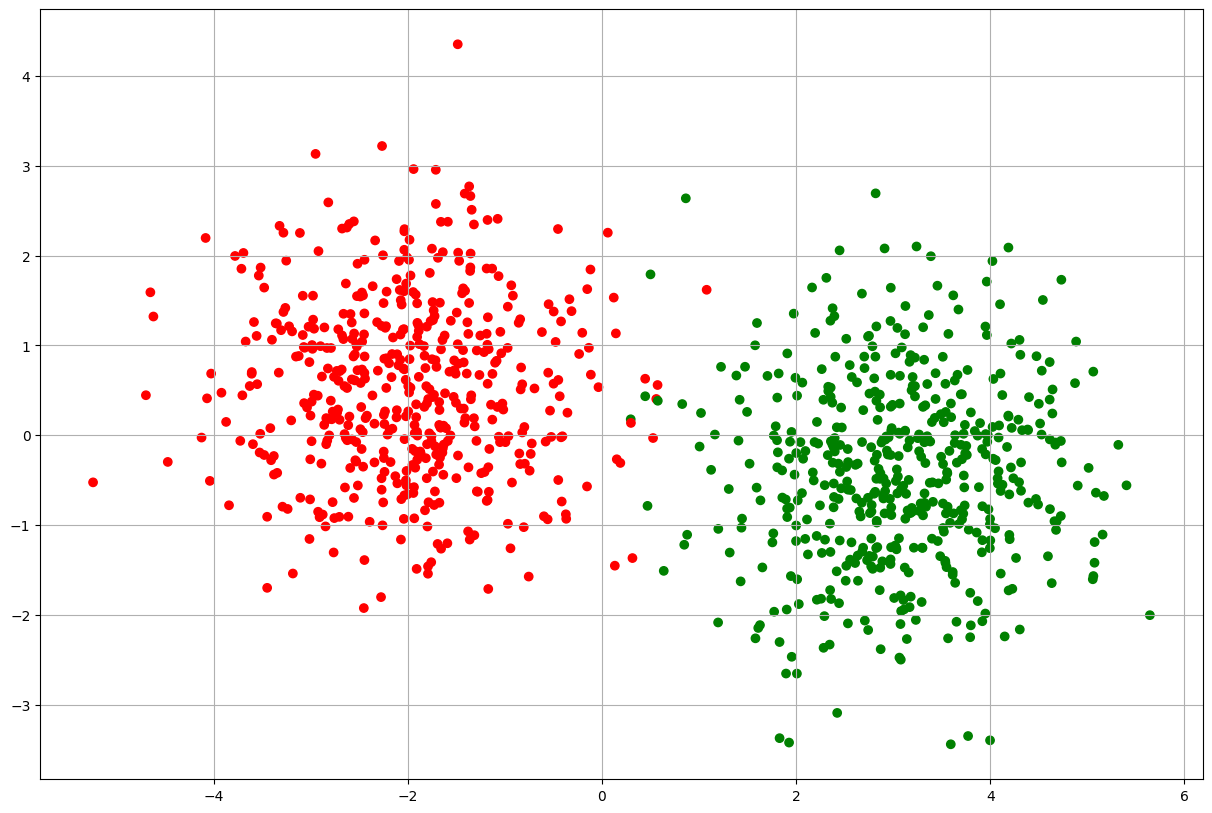

In [21]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples=1000, centers=[[-2, 0.5], [3, -0.5]], cluster_std=1, random_state=42)

colors = ("red", "green")
colored_y = np.zeros(y.size, dtype=str)

for i, cl in enumerate([0, 1]):
    colored_y[y.ravel() == cl] = str(colors[i])

plt.figure(figsize=(15, 10))
plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.grid()
plt.show()

In [22]:
clf = MyElasticLogisticRegression(0.1, 0.1)
clf.fit(X, y, epochs=1000)
w = clf.get_weights()
print(f"Веса модели: {w}")

Веса модели: [-1.43163011  3.07582242 -0.31424761]


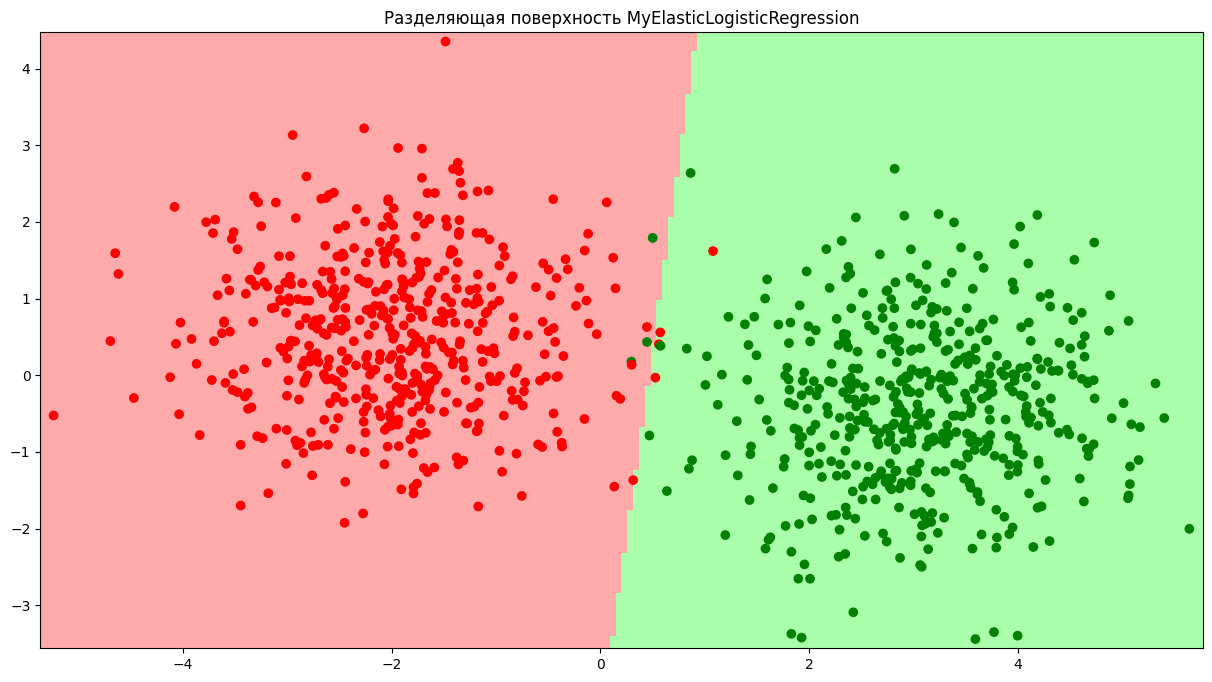

In [23]:
from matplotlib.colors import ListedColormap

plt.figure(figsize=(15, 8))

eps = 0.1
xx, yy = np.meshgrid(np.linspace(np.min(X[:, 0]) - eps, np.max(X[:, 0]) + eps, 200),
                     np.linspace(np.min(X[:, 1]) - eps, np.max(X[:, 1]) + eps, 200))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA'])
plt.pcolormesh(xx, yy, Z, cmap=cmap_light)

plt.scatter(X[:, 0], X[:, 1], c=colored_y)
plt.title('Разделяющая поверхность MyElasticLogisticRegression')
plt.show()

# MNIST: классификация цифр 0 и 1

Протестируем на датасете MNIST — классическом датасете рукописных цифр 28×28.

In [24]:
data = pd.read_csv('data/train.csv')
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [25]:
X = data.iloc[:, 1:]
y = data.iloc[:, 0]

# Выберем только картинки, где изображены 0 и 1
X = X[(y == 0) | (y == 1)]
y = y[(y == 0) | (y == 1)]

print(f"Размер выборки: X={X.shape}, y={y.shape}")
print(f"Распределение классов: {dict(y.value_counts())}")

Размер выборки: X=(8816, 784), y=(8816,)
Распределение классов: {1: np.int64(4684), 0: np.int64(4132)}


## Задание 6

Pipeline с StandardScaler + MyElasticLogisticRegression, оценка через cross_val_score.

In [26]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Pipeline: стандартизация + наша логистическая регрессия с регуляризацией
pipe = make_pipeline(StandardScaler(), MyElasticLogisticRegression(0.01, 0.01))

scores = cross_val_score(pipe, X.values, y.values, scoring='accuracy', cv=5)
mean_accuracy = scores.mean()

print(f"Scores по фолдам: {scores}")
print(f"Mean accuracy of Logistic Regression for two classes is {mean_accuracy}")

/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_40158/186220842.py:5: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(-h))
/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_40158/186220842.py:5: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(-h))


/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_40158/186220842.py:5: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(-h))
/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_40158/186220842.py:5: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(-h))
/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_40158/186220842.py:5: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(-h))


Scores по фолдам: [0.99546485 0.99773114 0.9960295  0.99546228 0.99773114]
Mean accuracy of Logistic Regression for two classes is 0.9964837816389555


/var/folders/13/pqnv3b791_l1507lm67lcx6h0000gn/T/ipykernel_40158/186220842.py:5: RuntimeWarning: overflow encountered in exp
  return 1. / (1 + np.exp(-h))
